# Evaluation -- Ohashi ResNet50 Baseline on LDCT-IQAC (Test Set)

## Objective

Evaluate a **trained** Ohashi-ResNet50 checkpoint against the held-out
LDCT-IQAC test set. This notebook is independent of the training notebook
(`notebooks/03_training/01_resnet50_baseline.ipynb`) -- it loads the model
from `experiments/001_resnet50_baseline/checkpoint/best.pt` rather than
relying on any in-memory state, so it can be re-run on its own at any time.

If no checkpoint exists yet (no full training run has been executed), this
notebook still runs end-to-end as a **pipeline sanity check** against a
freshly-initialized model -- the resulting numbers are explicitly reported
as such, never as a real result.

## Configuration

Loaded from the same `configs/*.yaml` files as training, via
`ExperimentConfig.from_yaml_files()` -- the single authoritative
configuration source (see `src/ct_iqa/config.py`).

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/04_evaluation/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))  # only needed until `pip install -e .` is run
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import json

import matplotlib.pyplot as plt
import torch

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import SCORE_MIN, SCORE_MAX
from ct_iqa.data.loader import build_test_dataloader
from ct_iqa.evaluation.metrics import compute_metrics, compute_metrics_with_logistic_mapping
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint
from ct_iqa.training.losses import build_loss
from ct_iqa.training.trainer import evaluate_loader

config = ExperimentConfig.from_yaml_files(
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print(f"experiment_dir : {config.experiment_dir}")
print(f"checkpoint_dir : {config.checkpoint_dir}")
config

experiment_dir : experiments/001_resnet50_baseline
checkpoint_dir : experiments\001_resnet50_baseline\checkpoint


ExperimentConfig(seed=42, batch_size=64, epochs=30, learning_rate=0.001, optimizer='adam', loss='mse', image_size=224, dropout_p=0.5, in_channels=1, train_image_dir='data/raw/ldct_iqac/train/image', train_json_path='data/labels/ldct_iqac/train.json', test_image_dir='data/raw/ldct_iqac/test/images', test_json_path='data/labels/ldct_iqac/test.json', val_fraction=0.1, radimagenet_weights_path='weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt', experiment_dir='experiments/001_resnet50_baseline', device='cuda')

## Data

In [3]:
test_loader = build_test_dataloader(config)
print(f"test batches : {len(test_loader)}  ({len(test_loader.dataset)} samples)")

test batches : 5  (300 samples)


## Model

Build the same architecture as training (`OhashiResNet50` -- defined only
in `src/ct_iqa/models/`), then load the saved checkpoint's weights. If no
checkpoint is present, the model is evaluated at its (random) initial
weights and this is reported explicitly rather than silently proceeding as
if it were a real result.

In [4]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)
model.to(config.device)

checkpoint_path = best_checkpoint_path(config.checkpoint_dir)
if checkpoint_path.exists():
    load_checkpoint(model, config.checkpoint_dir, map_location=config.device)
    CHECKPOINT_LOADED = True
    print(f"loaded checkpoint: {checkpoint_path}")
else:
    CHECKPOINT_LOADED = False
    print(f"NO CHECKPOINT FOUND at {checkpoint_path}.")
    print("Evaluating an UNTRAINED model -- this is a pipeline sanity check, not a real result.")

NO CHECKPOINT FOUND at experiments\001_resnet50_baseline\checkpoint\best.pt.
Evaluating an UNTRAINED model -- this is a pipeline sanity check, not a real result.


## Evaluation

Raw-space metrics (MSE, PLCC, SROCC, KROCC -- `ct_iqa.evaluation.metrics`)
and, separately, the Ohashi paper's 5-parameter-logistic-mapped metrics
(`ct_iqa.evaluation.calibration`). The two are never conflated -- both are
reported, labeled.

In [5]:
criterion = build_loss(config)
test_loss, test_predictions, test_targets = evaluate_loader(model, test_loader, criterion, device=config.device)
print(f"test loss (normalized-space MSE): {test_loss:.6f}")
if not CHECKPOINT_LOADED:
    print("(UNTRAINED MODEL -- pipeline sanity check only.)")

raw_metrics = compute_metrics(test_targets.numpy(), test_predictions.numpy())
print("Raw-space metrics (no logistic mapping):")
for k, v in raw_metrics.items():
    print(f"  {k.upper():6s}: {v:.4f}")

test loss (normalized-space MSE): 0.074863
(UNTRAINED MODEL -- pipeline sanity check only.)
Raw-space metrics (no logistic mapping):
  MSE   : 1.1978
  PLCC  : -0.5349
  SROCC : -0.5242
  KROCC : -0.3811


In [6]:
try:
    logistic_metrics = compute_metrics_with_logistic_mapping(test_targets.numpy(), test_predictions.numpy())
    print("5PL-mapped metrics:")
    for k, v in logistic_metrics.items():
        print(f"  {k.upper():6s}: {v:.4f}")
except Exception as e:
    print(f"5PL fit did not converge (expected with an under-trained/random model): {e}")
    logistic_metrics = None

5PL-mapped metrics:
  MSE   : 1.1819
  PLCC  : -0.5349
  SROCC : -0.5242
  KROCC : -0.3811


## Results

Predicted-vs-ground-truth scatter plot and persistence of predictions/
metrics to `results/` -- kept separate from the model checkpoint itself
(`experiments/001_resnet50_baseline/checkpoint/`), per the
checkpoints-vs-evaluation-outputs separation in
docs/repository_architecture_audit.md.

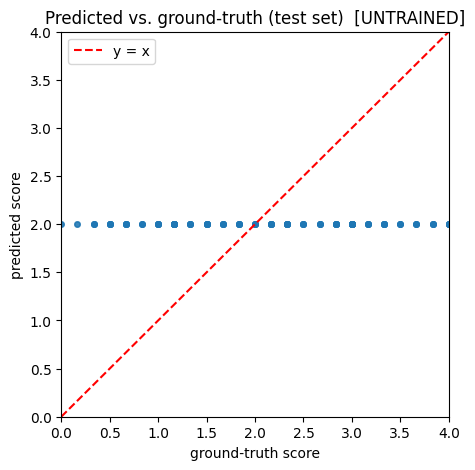

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(test_targets.numpy(), test_predictions.numpy(), alpha=0.5, s=15)
plt.plot([SCORE_MIN, SCORE_MAX], [SCORE_MIN, SCORE_MAX], "r--", label="y = x")
plt.xlabel("ground-truth score")
plt.ylabel("predicted score")
plt.xlim(SCORE_MIN, SCORE_MAX)
plt.ylim(SCORE_MIN, SCORE_MAX)
plt.legend()
plt.title("Predicted vs. ground-truth (test set)" + ("" if CHECKPOINT_LOADED else "  [UNTRAINED]"))
plt.savefig("results/figures/01_test_set_predicted_vs_ground_truth.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
predictions_path = Path("results/predictions/01_test_set_evaluation.json")
predictions_path.parent.mkdir(parents=True, exist_ok=True)
predictions_record = {
    "checkpoint_loaded": CHECKPOINT_LOADED,
    "predictions": {
        fn: {"ground_truth": gt, "predicted": pred}
        for fn, gt, pred in zip(
            [s.filename for s in test_loader.dataset.samples],
            test_targets.tolist(),
            test_predictions.tolist(),
        )
    },
}
predictions_path.write_text(json.dumps(predictions_record, indent=2))
print(f"saved predictions to {predictions_path}")

metrics_path = Path("results/metrics/01_test_set_evaluation.json")
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_record = {"checkpoint_loaded": CHECKPOINT_LOADED, "raw": raw_metrics, "logistic_mapped": logistic_metrics}
metrics_path.write_text(json.dumps(metrics_record, indent=2))
print(f"saved metrics to {metrics_path}")

saved predictions to results\predictions\01_test_set_evaluation.json
saved metrics to results\metrics\01_test_set_evaluation.json


## Notes

- If `CHECKPOINT_LOADED` is `False` above, every number in this notebook is
  a pipeline sanity check against an untrained model, **not** a real
  evaluation result -- re-run `notebooks/03_training/01_resnet50_baseline.ipynb`
  with `RUN_FULL_TRAINING = True` first.
- Outputs are written to `results/figures/`, `results/predictions/`, and
  `results/metrics/` -- never into the experiment's `checkpoint/`
  subdirectory, keeping model weights and evaluation artifacts separate.